# Automated Modelling Pipeline (AMP)

![Alt text](img/amp.jpg)

* Automated modelling pipeline is a tool designed to __train, evaluate and deploy__ time-series forecasting models
* General purpose tool, still __spesific focus on energy, especially HVAC systems__
* Primary goal is to __reduce the engineering effort to build models__

Typical phases of AMP workflow are:
* Dataset creation (_out of the scope in this example_)
* Defining targets and forecast parameters
* Feature selection and processing
* Model selection and tuning
* Fitting and model evaluation
* Model deployment (_out of the scope in this example_)


# Example demo project to show the capabilities of AMP

## Forecasting electricity consumption of electric heated small apartments in Finland

Simple demonstration to show complete workflow using Automated Modelling Pipeline

AMP tool can be installed from git: __git clone https://github.com/vttresearch/automated_modelling_pipeline.git__

### Import all the necessary libraries

In [1]:
import pandas as pd
from amp.base import Target
from amp.preprocessing import basic_features
from amp.efp.models.lightgbm import LightGBMForecaster
from amp.tools import train_eval_tool
from amp.baselines import MeanBaseline, LagBaseline


In this example, __LightGBM__ is used. AMP support RandomForest, Neural Networks, Physics-based models etc.

Jupyter settings

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")
# Show all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Prevent column width truncation
pd.set_option("display.max_colwidth", None)

# Prevent row width truncation
pd.set_option("display.width", None)


### Loading data from preprocessed file

Data should be loaded into Pandas dataframe with fixed time interval and columns contains the features

Each row contains one observation (timestamp, feature 1, feature 2...)

In this example, raw data is loaded from Fingrid using multiple sources 

1. __Electricity consumption of electric heated households__ https://data.fingrid.fi/datasets/196 
2. __Temperature in one location in Finland (Oulu)__ https://data.fingrid.fi/datasets/360

Data is read from CSV, then preprocessed and combined into single Pandas dataframe

In [3]:
df = pd.read_csv('data/temp_ele.csv', sep=';')
df['timestamp'] = df['Unnamed: 0']
df.set_index('timestamp', inplace=True)
df.index = pd.to_datetime(df.index)
df = df[['ele', 't_out']]
df['ele'] = df['ele'] / 1000 # kWh -> MWh
df.head(10)

,ele,t_out
timestamp,,
2023-08-31 21:00:00+00:00,719.684094,17.106000
2023-08-31 22:00:00+00:00,616.270926,17.106000
2023-08-31 23:00:00+00:00,554.790947,17.106000
2023-09-01 00:00:00+00:00,508.033007,17.257050
2023-09-01 01:00:00+00:00,476.168063,18.118300
2023-09-01 02:00:00+00:00,470.476988,18.231000
2023-09-01 03:00:00+00:00,519.397735,17.734700
2023-09-01 04:00:00+00:00,532.458277,17.225000
2023-09-01 05:00:00+00:00,526.167505,16.862046


In [4]:
df.tail(10)

,ele,t_out
timestamp,,
2025-09-09 14:00:00+00:00,676.360089,17.56300
2025-09-09 15:00:00+00:00,715.757267,17.56300
2025-09-09 16:00:00+00:00,800.073637,17.56300
2025-09-09 17:00:00+00:00,865.731890,17.56300
2025-09-09 18:00:00+00:00,824.002180,17.56300
2025-09-09 19:00:00+00:00,986.435705,16.58025
2025-09-09 20:00:00+00:00,958.409045,16.54400
2025-09-09 21:00:00+00:00,773.150327,16.54400
2025-09-09 22:00:00+00:00,674.337322,16.54400


Dataframe __df__ is now ready to be used by AMP

Example dataset contains following features:

* __'ele'__ is electricity consumption of the Finnish electricity heated small apartments and
* __'t_out'__ is temperature in Oulu. We are using only one temperature measurement for simplicity. 


### Defining parameters for forecast

In [5]:
data_freq = 60  # The interval between measurements/forecasts in minutes
forecast_len = 24  # Forecast length (steps)
lead_time = 0  # Gap between current time and first forecast period. If lead time is 0, forecast start from the next timestep
test_period = ('2025-08-01', '2025-09-09')


![Alt text](img/forecast_parameters.jpg)

### Define targets that we want to forecast

In this case we want to forecast electricity consumption, i.e. __ele__ column in the dataframe. In AMP there is a helper class __Target__ for defining target

In [6]:
targets = [Target(output='ele')]

### Define features that we want to use. 

In this case we use helper method basic_features that returns __feature dictionary__ including useful time-based features. It can be modified with your custom features if needed

__Feature dictionary guides AMP what kind of features need to be created from the data and how to process those features__

In [7]:

features = basic_features(lead_time=lead_time,
                          forecast_len=forecast_len,
                          features=['lagged_target', 'weekday', 'hour', 'month', 't_out', 'holiday'],
                          target_lags=[24],
                          target_lag_len=24,
                          temp_lag=8
                         )


Following feature dictionary is created with three important things: _(feature name: {windows, type})_

In [8]:
features

{'lagged_target': {'windows': [(-24, -1)], 'type': 'numeric'},
 'weekday': {'windows': [(0, 23)], 'type': 'cyclical'},
 'hour': {'windows': [(0, 23)], 'type': 'cyclical'},
 'month': {'windows': [(0, 23)], 'type': 'cyclical'},
 't_out': {'windows': [(-8, 23)], 'type': 'numeric'},
 'holiday': {'windows': [(0, 23)], 'type': 'onehot'}}

Each __feature__ has two key parts:

__windows__ specifies the time range relative to the forecast point.
* Negative values → past values (lags).
* Positive values → future values (e.g., from known inputs like calendar or weather forecasts).
* Ranges like (0, 23) → features are created for each forecast horizon step.
  
__type__ determines how the feature is transformed or encoded:
* numeric → used directly as numbers.
* cyclical → transformed into sine/cosine pairs to capture repeating patterns (e.g., hours, weekdays, months).
* onehot → expanded into binary indicators for categorical variables.

__lagged_target__ is calculated from target value, __Weekday__, __hour__, __month__ and __holiday__ can be calculated based on the timestamp, __t_out__ needs to be found from data

Dictionary created by basic_features can be extended or replaced by manually defining features. For example if training dataset contains column LS1_power and it needs to be used as a feature, it can be defined as following:

```python
features = {}

ls1 = {'windows': [(lead_time, lead_time + forecast_len - 1)],
       'type': 'numeric'}

features['LS1_power'] = ls1


### Create LightGBM forecaster

In this example, we use LightGBM forecaster. In AMP you can add many different models to __model_dict__ and compare multiple models on the same time


In [9]:

model_dict = {'lightgbm_forecaster': LightGBMForecaster(targets=targets,
                                                        lead_time=lead_time,
                                                        forecast_len=forecast_len,
                                                        data_freq=data_freq,
                                                        features=features,
                                                        update_freq=1)}
model_dict



{'lightgbm_forecaster': <amp.efp.models.lightgbm.LightGBMForecaster at 0x12c54b7d0>}

In this example, we use default hyperparameteres for the forecaster

### Create baseline models for comparison

We can compare the performance of our forecasting models to baseline models

In [10]:

baselines = {'mean': MeanBaseline(),
             'lag_4': LagBaseline(4),
             'lag_24': LagBaseline(24)}


* __MeanBaseline__ computes the average of the historical data and uses it as a prediction for future values 
* __LagBaseline__ Predicts the future value based the value from n steps back.

### Using train eval tool first to fit the models

The function `train_eval_tool` is used to **train forecasting models, evaluate their performance, and compare them to simple baseline models**.  

In [11]:
train_eval_tool(
    mode='fit',
    targets=targets,
    models=model_dict,
    df=df,
    test_period=test_period,
    data_freq=data_freq,
    fcast_len=forecast_len,
    lead_time=lead_time,
    update_rate=1,
    baselines=baselines
)

INFO:ema:Fitting using features:

INFO:ema:
                   windows      type
lagged_target  [(-24, -1)]   numeric
weekday          [(0, 23)]  cyclical
hour             [(0, 23)]  cyclical
month            [(0, 23)]  cyclical
t_out           [(-8, 23)]   numeric
holiday          [(0, 23)]    onehot
INFO:ema:Fitting model for ele


Fitting lightgbm_forecaster
[ColumnTransformer] . (1 of 6) Processing lagged_target, total=   0.0s
[ColumnTransformer] ....... (2 of 6) Processing weekday, total=   0.0s
[ColumnTransformer] .......... (3 of 6) Processing hour, total=   0.0s
[ColumnTransformer] ......... (4 of 6) Processing month, total=   0.0s
[ColumnTransformer] ......... (5 of 6) Processing t_out, total=   0.0s
[ColumnTransformer] ....... (6 of 6) Processing holiday, total=   0.0s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14463
[LightGBM] [Info] Number of data points in the train set: 16756, number of used features: 110
[LightGBM] [Info] Start training from score 1268.966207
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can 

### Evaluating the models

Evaluating model: lightgbm_forecaster
Model lightgbm_forecaster prediction completed in 0.05 seconds.

Evaluating target variable: ele
----------------------------------------
Results for model: lightgbm_forecaster on target: ele
Calculating MSE for forecast period: forecast_0
MSE for model lightgbm_forecaster, target ele, period forecast_0: 380.2467
MAE: 14.390187507026642
MSE: 380.24671983215944
Mean: 711.3966695656251
Max: 1184.1271740000002, Min: 453.757968
RMSE: 19.49991589295091
NRMSE1: 0.027410749483628382
NRMSE2: 0.026698710368343356
Calculating MSE for forecast period: forecast_1
MSE for model lightgbm_forecaster, target ele, period forecast_1: 861.8962
MAE: 21.69287183353623
MSE: 861.8962063760713
Mean: 711.4118514854167
Max: 1184.1271740000002, Min: 453.757968
RMSE: 29.358068846163423
NRMSE1: 0.041267331693820165
NRMSE2: 0.04019620296828809
Calculating MSE for forecast period: forecast_2
MSE for model lightgbm_forecaster, target ele, period forecast_2: 1087.0128
MAE: 24.5217

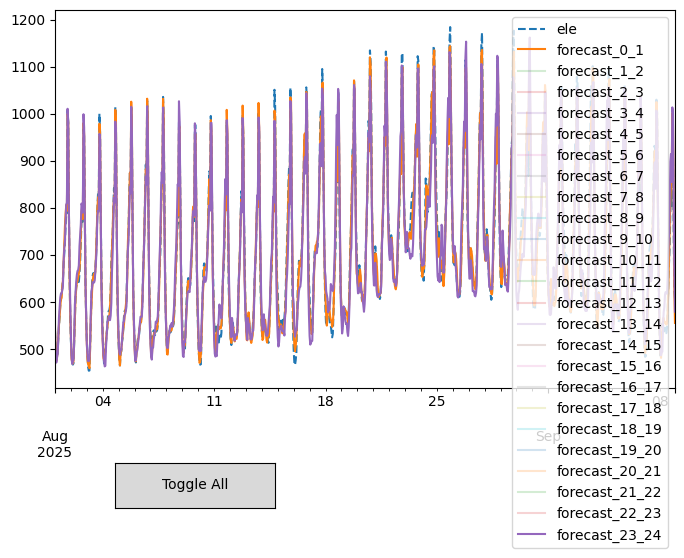

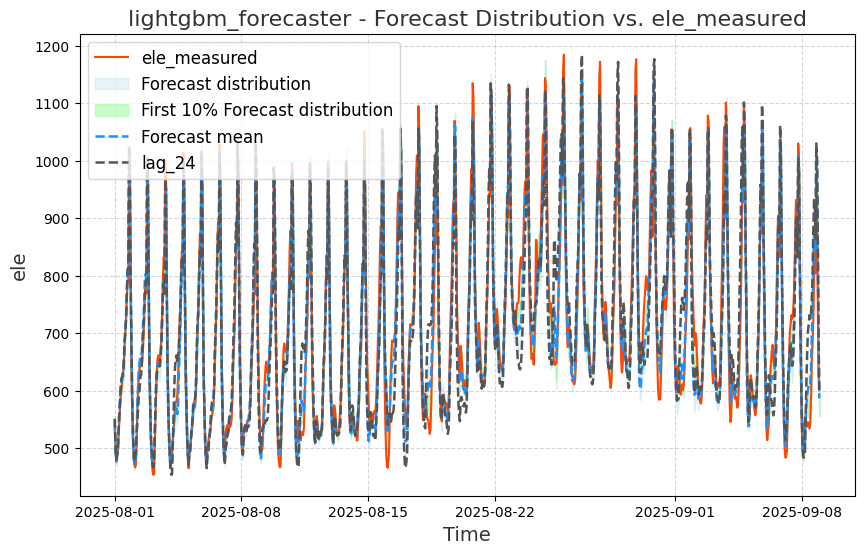

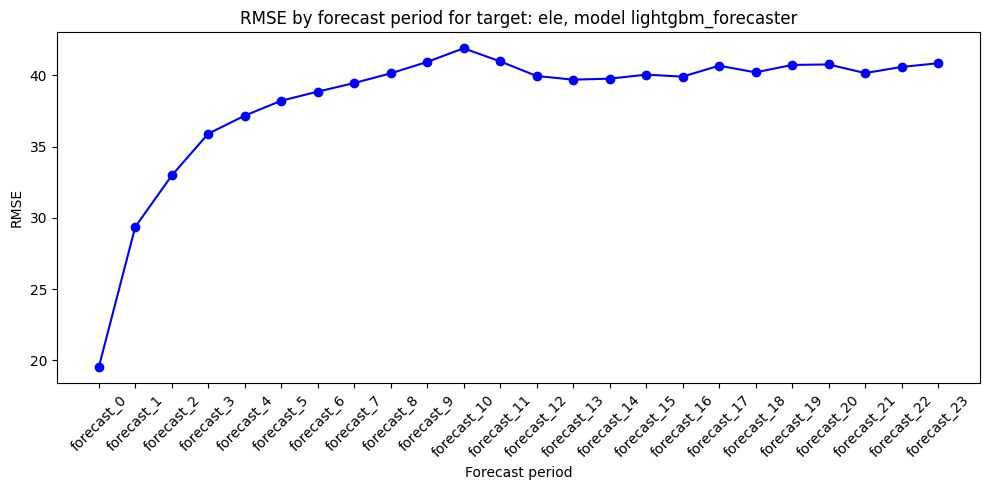

Saved forecast results for target ele to results/lightgbm_forecaster_ele.csv


In [12]:
train_eval_tool(mode='eval',
                targets=targets,
                models=model_dict,
                df=df,
                test_period=test_period,
                data_freq=data_freq,
                fcast_len=forecast_len,
                lead_time=lead_time,
                update_rate=1,
                baselines=baselines,
                plot='best',
                verbose=True)
